# SHAP Encoder Importance (2021)

This notebook loads the trained orthogonal model and analyzes, for each 2021 race instance, how much the **driver encoder** and **constructor encoder** contribute to the prediction.

For every instance, contributions are normalized so that:

`driver_importance_norm + constructor_importance_norm = 1`

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import shap
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../"))

from relbench.datasets import get_dataset
from train import filter_db_by_years, build_graph, _build_instances
from models.pipeline_fusion import F1OrthogonalPipeline
import config as cfg

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

/data/antonioneves/ortogonal-representation/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
MODEL_NAME = "model_orthogonal"
MODEL_PATH = f"../output/models/{MODEL_NAME}.pth"
LATENT_DIM = 32
YEAR = 2021
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BACKGROUND_SIZE = 256
RANDOM_SEED = 42
MIN_POSITIVE_RACES = 5
TOP_K = 20

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# ---------------------------------------------------------------------------
# Load DB, instances and graph metadata
# ---------------------------------------------------------------------------
dataset = get_dataset(cfg.RELBENCH_DATASET, download=True)
db = dataset.get_db(upto_test_timestamp=False)
db = filter_db_by_years(db, 2000, 2023)

instances = _build_instances(db)
instances_2021 = instances[instances["year"] == YEAR].copy().reset_index(drop=True)
if instances_2021.empty:
    raise RuntimeError(f"No instances found for year={YEAR}")

print(f"Total instances: {len(instances)}")
print(f"Instances in {YEAR}: {len(instances_2021)}")

graph_data, node_to_col_names_dict, node_to_col_stats = build_graph(db)
num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}

# Keep a CPU copy for TensorFrame inputs.
graph_cpu = graph_data
graph_data = graph_data.to(DEVICE)

drivers_df = db.table_dict["drivers"].df.reset_index(drop=True)
constructors_df = db.table_dict["constructors"].df.reset_index(drop=True)
races_df = db.table_dict["races"].df.reset_index(drop=True)

race_id_to_name = races_df.set_index("raceId")["name"].to_dict()
driver_id_to_name = drivers_df.set_index("driverId").apply(
    lambda r: f"{r['forename']} {r['surname']}", axis=1
).to_dict()
constructor_id_to_name = constructors_df.set_index("constructorId")["name"].to_dict()

Loading Database object from /home/nvidia/.cache/relbench/rel-f1/db...
Done in 0.03 seconds.
Total instances: 9400
Instances in 2021: 440


In [4]:
# ---------------------------------------------------------------------------
# Load trained model (checkpoint-compatible load)
# ---------------------------------------------------------------------------
def load_compatible_model(path):
    model = F1OrthogonalPipeline(
        num_nodes_dict=num_nodes_dict,
        node_to_col_names_dict=node_to_col_names_dict,
        node_to_col_stats=node_to_col_stats,
        latent_dim=LATENT_DIM,
    ).to(DEVICE)

    # Materialize lazy params before compatibility checks.
    if model.encoder is not None:
        with torch.no_grad():
            x_init = model.encoder(graph_cpu.tf_dict)
            _ = model.graph_encoder(x_init, graph_data.edge_index_dict)

    ckpt = torch.load(path, map_location=DEVICE)
    state = model.state_dict()

    compatible = {}
    skipped = []
    for k, v in ckpt.items():
        if k in state and state[k].shape == v.shape:
            compatible[k] = v
        elif k in state:
            skipped.append((k, tuple(v.shape), tuple(state[k].shape)))

    missing, unexpected = model.load_state_dict(compatible, strict=False)
    print(f"Loaded tensors: {len(compatible)}")
    print(f"Skipped shape mismatch tensors: {len(skipped)}")
    print(f"Missing keys: {len(missing)}, Unexpected keys: {len(unexpected)}")

    model.eval()
    return model

model = load_compatible_model(MODEL_PATH)

Loaded tensors: 471
Skipped shape mismatch tensors: 4
Missing keys: 4, Unexpected keys: 0


In [5]:
# ---------------------------------------------------------------------------
# Compute per-instance latent vectors and predictions for 2021
# ---------------------------------------------------------------------------
with torch.no_grad():
    driver_ids = torch.tensor(instances_2021["driverId"].values, dtype=torch.long, device=DEVICE)
    constructor_ids = torch.tensor(instances_2021["constructorId"].values, dtype=torch.long, device=DEVICE)

    logits, _, _, v_driver, v_constructor, _ = model(
        graph_x_dict=None,
        graph_edge_index_dict=graph_data.edge_index_dict,
        target_constructor_ids=constructor_ids,
        target_driver_ids=driver_ids,
        graph_tf_dict=graph_cpu.tf_dict,
    )

    probs = torch.sigmoid(logits.squeeze(-1)).detach().cpu().numpy()
    v_driver_np = v_driver.detach().cpu().numpy()
    v_constructor_np = v_constructor.detach().cpu().numpy()

fused_np = np.concatenate([v_driver_np, v_constructor_np], axis=1)
fused_tensor = torch.tensor(fused_np, dtype=torch.float32, device=DEVICE)

print(f"Latent shape driver: {v_driver_np.shape}")
print(f"Latent shape constructor: {v_constructor_np.shape}")
print(f"Fused shape: {fused_np.shape}")

Latent shape driver: (440, 32)
Latent shape constructor: (440, 32)
Fused shape: (440, 64)


In [6]:
# ---------------------------------------------------------------------------
# SHAP over fused latent space and encoder-level normalized contributions
# ---------------------------------------------------------------------------
class HeadOnlyModel(nn.Module):
    def __init__(self, classifier):
        super().__init__()
        self.classifier = classifier

    def forward(self, x):
        return self.classifier(x)

head_model = HeadOnlyModel(model.classifier).to(DEVICE)
head_model.eval()

bg_size = min(BACKGROUND_SIZE, fused_tensor.shape[0])
bg_idx = np.random.choice(fused_tensor.shape[0], size=bg_size, replace=False)
background = fused_tensor[bg_idx]

explainer = shap.GradientExplainer(head_model, background)
shap_values = explainer.shap_values(fused_tensor)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.detach().cpu().numpy()

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

shap_abs = np.abs(shap_values)
driver_raw = shap_abs[:, :LATENT_DIM].sum(axis=1)
constructor_raw = shap_abs[:, LATENT_DIM:].sum(axis=1)

den = driver_raw + constructor_raw + 1e-12
driver_norm = driver_raw / den
constructor_norm = constructor_raw / den

importance_check = np.max(np.abs((driver_norm + constructor_norm) - 1.0))
print(f"Max normalization error (should be ~0): {importance_check:.2e}")

Max normalization error (should be ~0): 1.18e-12


In [7]:
# ---------------------------------------------------------------------------
# Build analysis tables, positive-only ranking, and confidence intervals
# ---------------------------------------------------------------------------
analysis_df = instances_2021.copy()
analysis_df["prediction_prob_top3"] = probs
analysis_df["driver_importance_raw"] = driver_raw
analysis_df["constructor_importance_raw"] = constructor_raw
analysis_df["driver_importance_norm"] = driver_norm
analysis_df["constructor_importance_norm"] = constructor_norm

analysis_df["driver_name"] = analysis_df["driverId"].map(driver_id_to_name)
analysis_df["constructor_name"] = analysis_df["constructorId"].map(constructor_id_to_name)
analysis_df["race_name"] = analysis_df["raceId"].map(race_id_to_name)

# Global (all instances) table kept for comparison.
per_driver = (
    analysis_df
    .groupby(["driverId", "driver_name"], as_index=False)
    .agg(
        races=("raceId", "count"),
        mean_prediction_prob_top3=("prediction_prob_top3", "mean"),
        mean_driver_importance=("driver_importance_norm", "mean"),
        mean_constructor_importance=("constructor_importance_norm", "mean"),
    )
)

# Positive-only subset: top3 == 1 means beneficial outcomes.
positive_df = analysis_df[analysis_df["top3"] == 1].copy()

per_driver_positive = (
    positive_df
    .groupby(["driverId", "driver_name"], as_index=False)
    .agg(
        positive_races=("raceId", "count"),
        mean_prediction_prob_top3_positive=("prediction_prob_top3", "mean"),
        mean_driver_importance_positive=("driver_importance_norm", "mean"),
        std_driver_importance_positive=("driver_importance_norm", "std"),
        mean_constructor_importance_positive=("constructor_importance_norm", "mean"),
        total_driver_importance_positive=("driver_importance_norm", "sum"),
        total_constructor_importance_positive=("constructor_importance_norm", "sum"),
    )
)

# Apply minimum positive-race filter selected for ranking stability.
per_driver_positive = per_driver_positive[
    per_driver_positive["positive_races"] >= MIN_POSITIVE_RACES
].copy()

# 95% CI for split point on positive-only samples.
per_driver_positive["std_driver_importance_positive"] = per_driver_positive[
    "std_driver_importance_positive"
].fillna(0.0)
per_driver_positive["driver_ci95_positive"] = (
    1.96
    * per_driver_positive["std_driver_importance_positive"]
    / np.sqrt(per_driver_positive["positive_races"].clip(lower=1))
)
per_driver_positive["driver_ci95_low_positive"] = (
    per_driver_positive["mean_driver_importance_positive"]
    - per_driver_positive["driver_ci95_positive"]
).clip(0, 1)
per_driver_positive["driver_ci95_high_positive"] = (
    per_driver_positive["mean_driver_importance_positive"]
    + per_driver_positive["driver_ci95_positive"]
).clip(0, 1)

per_driver_positive["driver_minus_constructor_positive"] = (
    per_driver_positive["mean_driver_importance_positive"]
    - per_driver_positive["mean_constructor_importance_positive"]
)

# Sanity check for normalized split in the positive-only ranking table.
positive_norm_gap = (
    per_driver_positive["mean_driver_importance_positive"]
    + per_driver_positive["mean_constructor_importance_positive"]
    - 1.0
).abs().max()
print(f"Positive-only rows: {len(positive_df)}")
print(f"Drivers kept with at least {MIN_POSITIVE_RACES} positive races: {len(per_driver_positive)}")
print(f"Max positive-only normalization gap: {positive_norm_gap:.2e}")

rank_driver_positive = per_driver_positive.sort_values(
    ["mean_driver_importance_positive", "positive_races"], ascending=[False, False]
).reset_index(drop=True)

print("Top positive-only drivers by DRIVER encoder importance:")
display(rank_driver_positive.head(TOP_K))

Positive-only rows: 66
Drivers kept with at least 5 positive races: 4
Max positive-only normalization gap: 4.33e-13
Top positive-only drivers by DRIVER encoder importance:


,driverId,driver_name,positive_races,mean_prediction_prob_top3_positive,mean_driver_importance_positive,std_driver_importance_positive,mean_constructor_importance_positive,total_driver_importance_positive,total_constructor_importance_positive,driver_ci95_positive,driver_ci95_low_positive,driver_ci95_high_positive,driver_minus_constructor_positive
0,0,Lewis Hamilton,17,0.526051,0.489225,0.009228,0.510775,8.316821,8.683179,0.004387,0.484838,0.493611,-0.021551
1,829,Max Verstappen,18,0.459262,0.406809,0.012284,0.593191,7.322560,10.677440,0.005675,0.401134,0.412484,-0.186382
2,821,Valtteri Bottas,11,0.487717,0.356249,0.012692,0.643751,3.918740,7.081260,0.007501,0.348748,0.363750,-0.287502
3,814,Sergio Pérez,5,0.325442,0.140510,0.008883,0.859490,0.702549,4.297451,0.007787,0.132723,0.148296,-0.718980


In [8]:
# ---------------------------------------------------------------------------
# Ranking: all drivers in 2021 (all instances, SHAP normalized importance)
# ---------------------------------------------------------------------------
rank_driver_all = per_driver.sort_values(
    ["mean_driver_importance", "races"], ascending=[False, False]
).reset_index(drop=True)

print(f"All-driver ranking rows (2021): {len(rank_driver_all)}")
print("Ranking by DRIVER encoder importance on all 2021 instances:")
display(rank_driver_all)

All-driver ranking rows (2021): 21
Ranking by DRIVER encoder importance on all 2021 instances:


,driverId,driver_name,races,mean_prediction_prob_top3,mean_driver_importance,mean_constructor_importance
0,3,Fernando Alonso,22,0.182135,0.807560,0.192440
1,19,Sebastian Vettel,22,0.260453,0.795960,0.204040
2,847,Nicholas Latifi,22,0.007242,0.752159,0.247841
3,838,Esteban Ocon,22,0.020866,0.612951,0.387049
4,839,Lance Stroll,22,0.012372,0.558715,0.441285
5,845,George Russell,22,0.019967,0.549043,0.450957
6,851,Nikita Mazepin,22,0.001252,0.514532,0.485468
7,0,Lewis Hamilton,22,0.526051,0.489331,0.510669
8,840,Antonio Giovinazzi,22,0.001989,0.475990,0.524010
9,7,Kimi Räikkönen,20,0.040515,0.454119,0.545881


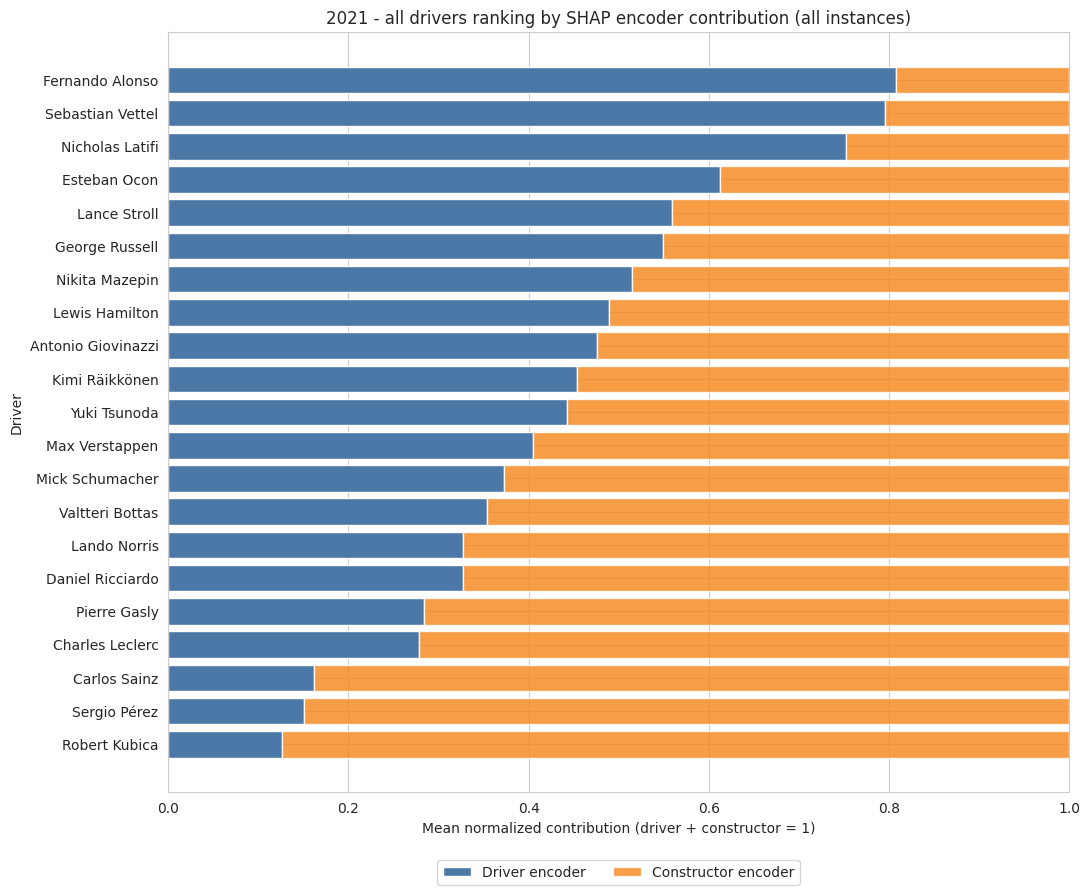

In [9]:
# ---------------------------------------------------------------------------
# Visualization: all drivers in 2021 (all instances)
# ---------------------------------------------------------------------------
plot_all_df = rank_driver_all.copy().iloc[::-1]
y_all = np.arange(len(plot_all_df))

plt.figure(figsize=(11, 9))
plt.barh(
    y_all,
    plot_all_df["mean_driver_importance"],
    label="Driver encoder",
    color="#4C78A8",
)
plt.barh(
    y_all,
    plot_all_df["mean_constructor_importance"],
    left=plot_all_df["mean_driver_importance"],
    label="Constructor encoder",
    alpha=0.8,
    color="#F58518",
)

plt.title(f"{YEAR} - all drivers ranking by SHAP encoder contribution (all instances)")
plt.xlabel("Mean normalized contribution (driver + constructor = 1)")
plt.ylabel("Driver")
plt.yticks(y_all, plot_all_df["driver_name"])
plt.xlim(0, 1)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

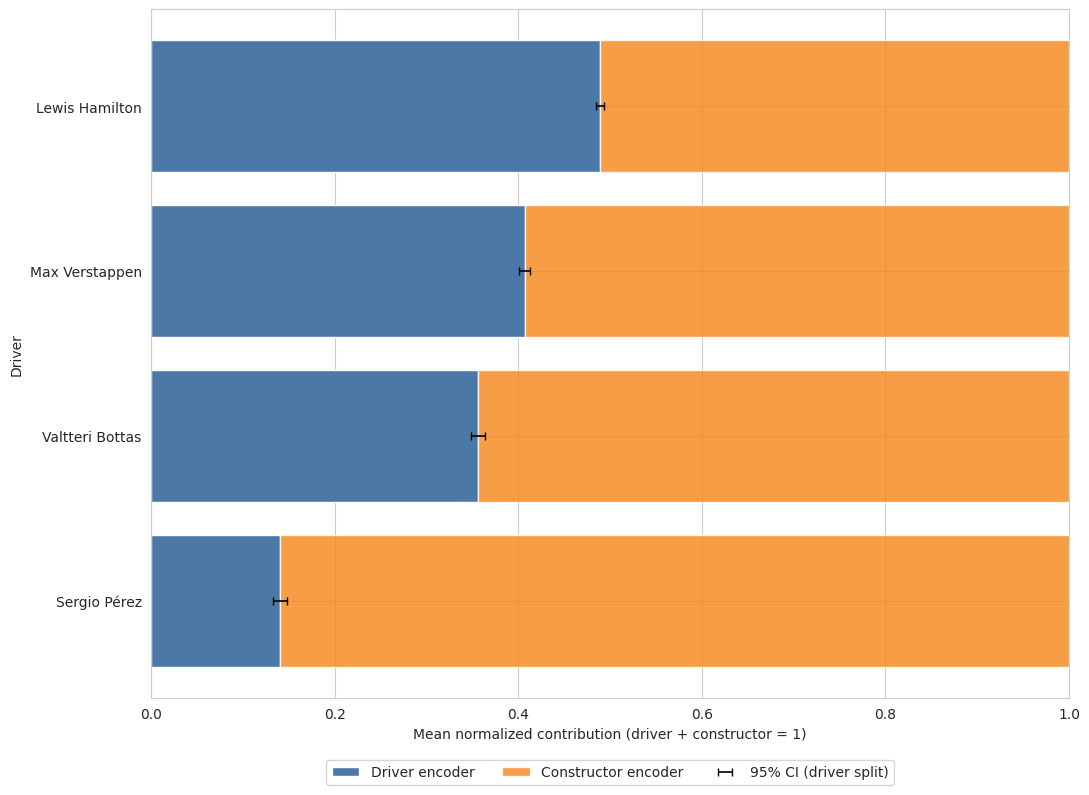

In [10]:
# ---------------------------------------------------------------------------
# Visualization: positive-only ranking (top drivers) + 95% CI
# ---------------------------------------------------------------------------
plot_df = rank_driver_positive.head(TOP_K).copy().iloc[::-1]
y_pos = np.arange(len(plot_df))

plt.figure(figsize=(11, 8))
plt.barh(
    y_pos,
    plot_df["mean_driver_importance_positive"],
    label="Driver encoder",
    color="#4C78A8",
)
plt.barh(
    y_pos,
    plot_df["mean_constructor_importance_positive"],
    left=plot_df["mean_driver_importance_positive"],
    label="Constructor encoder",
    alpha=0.8,
    color="#F58518",
)

# Place 95% CI exactly at the transition point between driver and constructor segments.
x_center = plot_df["mean_driver_importance_positive"].values
xerr_left = x_center - plot_df["driver_ci95_low_positive"].values
xerr_right = plot_df["driver_ci95_high_positive"].values - x_center
plt.errorbar(
    x=x_center,
    y=y_pos,
    xerr=[xerr_left, xerr_right],
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=3,
    label="95% CI (driver split)",
)

# plt.title(
  #  f"{YEAR} Positive-only (top3=1) - driver importance ranking (top {TOP_K}, min {MIN_POSITIVE_RACES} races)"
# )
plt.xlabel("Mean normalized contribution (driver + constructor = 1)")
plt.ylabel("Driver")
plt.yticks(y_pos, plot_df["driver_name"])
plt.xlim(0, 1)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=True)
plt.tight_layout()
plt.show()

In [11]:
# Optional: save detailed outputs
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

analysis_df.to_csv(f"{OUTPUT_DIR}/shap_encoder_importance_instances_{YEAR}.csv", index=False)
per_driver.to_csv(f"{OUTPUT_DIR}/shap_encoder_importance_driver_rank_{YEAR}.csv", index=False)
positive_df.to_csv(f"{OUTPUT_DIR}/shap_encoder_importance_instances_{YEAR}_positive_only.csv", index=False)
rank_driver_positive.to_csv(
    f"{OUTPUT_DIR}/shap_encoder_importance_driver_rank_{YEAR}_positive_only_with_threshold{MIN_POSITIVE_RACES}.csv",
    index=False,
)
rank_driver_positive.to_csv(
    f"{OUTPUT_DIR}/shap_encoder_importance_driver_rank_{YEAR}_positive_only.csv",
    index=False,
)
print("Saved CSV files in notebooks/output/")

Saved CSV files in notebooks/output/
